## 1. Problem Definition
- **Objective:** Build a complete end-to-end machine learning solution to predict taxi `trip_duration`
- **Type:** Regression
- **Business Goal:** Predict trip duration to optimize taxi dispatch, reduce wait time.

## Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
import joblib

In [13]:
df = pd.read_csv("train.csv")

In [14]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [15]:
df.shape

(1458644, 11)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


### Checking Data Distribution

In [17]:
df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

                  mean  median          std   count
vendor_id                                          
1           845.438244   658.0  6147.911115  678342
2          1058.643164   666.0  4289.286883  780302


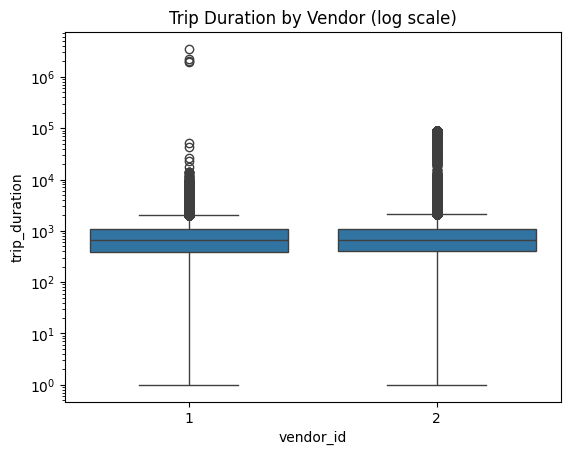

In [18]:
print(df.groupby("vendor_id")["trip_duration"].agg(["mean", "median", "std", "count"]))
sns.boxplot(data=df, x="vendor_id", y="trip_duration")
plt.yscale("log")
plt.title("Trip Duration by Vendor (log scale)")
plt.show()

| Metric | Vendor 1 | Vendor 2    |
| ------ | -------------- | ------------------ |
| Mean   | 845s           | 1,059s​             |
| Median | 658-666s       | 666s               |
| Std    | 6,148s         | 4,289s             |
| Count  | 678k           | 780k               |

## Vendor Trip Duration Comparison

**Average Trip Duration**
- **Vendor 2:** 1,059s (~17.6 min)
- **Vendor 1:** 845s (~14.1 min)

**Median Trip Duration**
- Both vendors: **666s** (~11.1 min)

**Standard Deviation**
- **Vendor 2:** 4,289s
- **Vendor 1:** 6,148s

---

### Key Insight
Although Vendor 2 shows a higher **average** trip duration, the **medians are identical**, indicating similar typical trip lengths. The higher mean for Vendor 2 is driven by **extreme long trips**, which pull the average upward despite comparable trip distributions.

In [19]:
df["passenger_count"].value_counts()

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64

In [20]:
df.isnull().isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [21]:
df.groupby("vendor_id")["passenger_count"].value_counts().to_frame()

count
vendor_id passenger_count        
1         1                550787
          2                 92142
          3                 22942
          4                 11944
          5                   344
          6                   152
          0                    31
2         1                482753
          2                118176
          5                 77744
          6                 48181
          3                 36954
          4                 16460
          0                    29
          7                     3
          8                     1
          9                     1

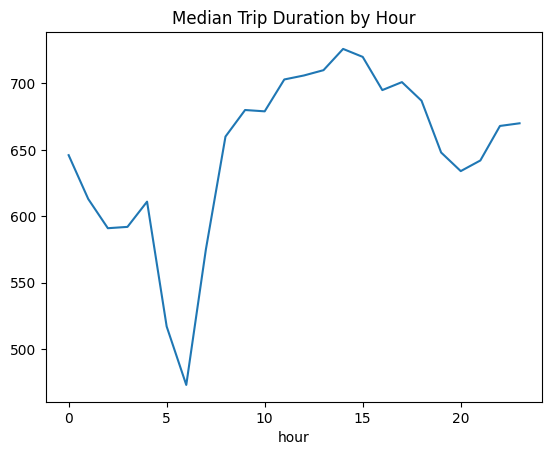

In [22]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour
df["dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["month"] = df["pickup_datetime"].dt.month

df.groupby("hour")["trip_duration"].median().plot(title="Median Trip Duration by Hour")
plt.show()

## Trip Duration by Time of Day Analysis

#### Overnight (12 AM–5 AM) — ~590–650s
- Trips are moderately long around midnight (~650s).
- Duration gradually dips through early morning hours.
- Light traffic allows faster routing, but trips may cover longer distances.

---

#### 6 AM — Sharp Minimum (~450s)
- **Lowest point of the entire day.**
- Drivers cover distances quickly with almost no congestion.
- Represents the fastest average travel time window.

---

#### Morning → Afternoon (7 AM–3 PM) — Rising to ~700+s
- Trip duration increases steadily as traffic builds.
- Congestion accumulates through late morning.
- Peak duration occurs around **2–3 PM**.

---

#### Evening Dip (8–9 PM) — ~600–650s
- Secondary low period.
- Traffic eases after rush hour.
- Faster trips compared to late afternoon peak.

---

#### Late Night (10 PM–12 AM) — ~650+s
- Trip duration increases again.
- Likely driven by longer-distance trips despite lighter traffic.

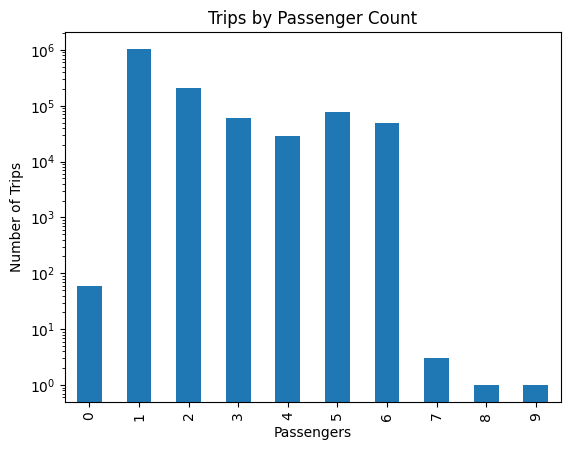

In [23]:
ax = df["passenger_count"].value_counts().sort_index().plot(kind="bar")
ax.set_yscale("log")
plt.title("Trips by Passenger Count")
plt.xlabel("Passengers")
plt.ylabel("Number of Trips")
plt.show()

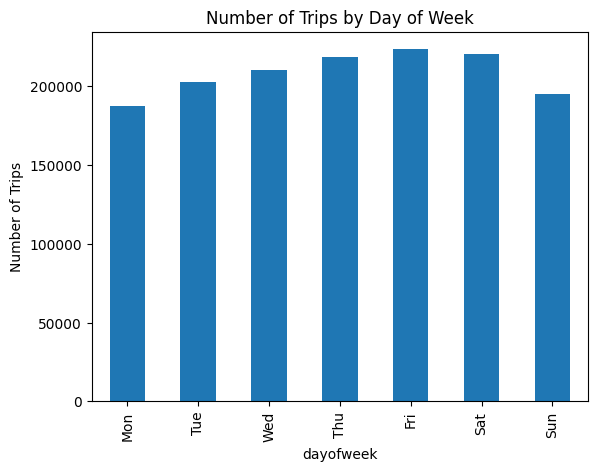

In [24]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["dayofweek"] = df["pickup_datetime"].dt.dayofweek

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["dayofweek"].value_counts().sort_index().plot(kind="bar")
plt.xticks(range(7), day_names)
plt.title("Number of Trips by Day of Week")
plt.ylabel("Number of Trips")
plt.show()

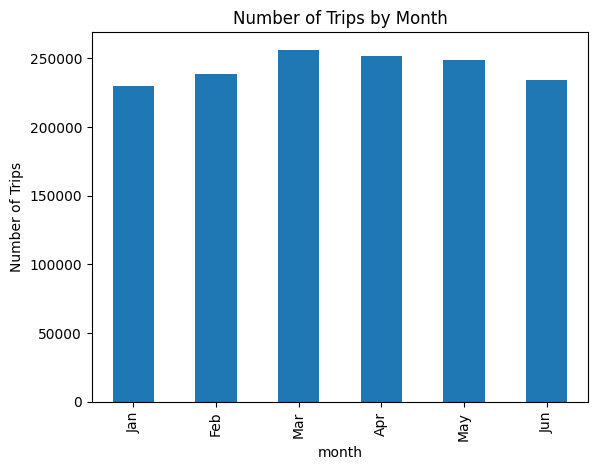

In [25]:
df["month"] = df["pickup_datetime"].dt.month
df["month"].value_counts().sort_index().plot(kind="bar")
plt.xticks(range(6), ["Jan", "Feb", "Mar", "Apr", "May", "Jun"])
plt.title("Number of Trips by Month")
plt.ylabel("Number of Trips")
plt.show()

## Trips by Day of Week

- **Friday** is the busiest (~200k+ trips) — end of workweek, more outings.
- **Monday** is the quietest (~180k+ trips).
- Trips steadily increase from **Monday → Friday**, then dip slightly on weekends.
- Differences between days are relatively small.

--- 

## Trips by Month (Jan–Jun Only)

- Dataset covers **January through June** only.
- **March** is the peak (~250k+ trips).
- **June** is slightly lower (~230k+ trips).
- Differences across months are small.
- Overall distribution is fairly flat.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
 11  hour                1458644 non-null  int32         
 12  dayofweek           1458644 non-null  int32         
 13  month       

In [27]:
df.head(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,dayofweek,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1


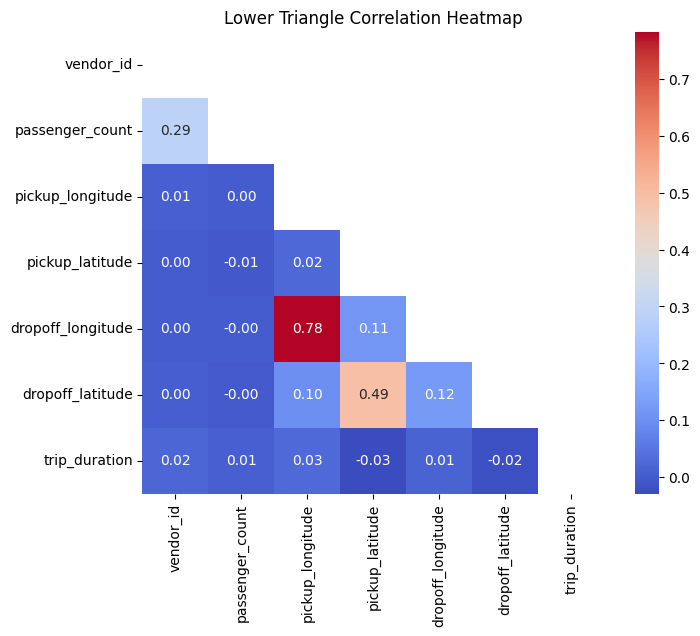

In [28]:
num_cols = [
    "vendor_id",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration",
]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Lower Triangle Correlation Heatmap")
plt.show()

In [29]:
df.head(1)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,dayofweek,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.96463,40.765602,N,455,17,0,3


In [30]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month
df["pickup_is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

In [31]:
df.drop(columns=["hour", "dayofweek", "month"], inplace=True, errors="ignore")

In [32]:
if df["store_and_fwd_flag"].dtype == "object":
    df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({"N": 0, "Y": 1})

df["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
0    1450599
1       8045
Name: count, dtype: int64

In [33]:
df.head(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,pickup_is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,3,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,6,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,1,1,0


## Issue & Fix

**Issue:**  
Running `.map()` again on a column already converted to `0` and `1` caused all values to become `NaN` (since `0` and `1` weren’t in the mapping dictionary).

**Fix:**  
Apply `.map()` only if the column is `object` type condition.

#### Haversine Formula

```python
a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2

In [34]:
def haversine_np(df):
    lat1 = np.radians(df["pickup_latitude"])
    lon1 = np.radians(df["pickup_longitude"])
    lat2 = np.radians(df["dropoff_latitude"])
    lon2 = np.radians(df["dropoff_longitude"])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))  # earth's radius (6371 km)


df["distance_haversine"] = haversine_np(df)

### Haversine Distance Steps

1. **How far north/south?** → `dlat`  
2. **How far east/west?** → `dlon` (shrinks near poles via `cos`)  
3. **Combine them** → `a`  
4. **Convert to km on Earth** → `6371 × 2 × arcsin(√a)`

In [35]:
df["distance_manhattan"] = abs(df["pickup_latitude"] - df["dropoff_latitude"]) + abs(
    df["pickup_longitude"] - df["dropoff_longitude"]
)

In [36]:
(df["distance_manhattan"] < 0).any()

False

In [37]:
df["bearing"] = np.degrees(
    np.arctan2(
        df["dropoff_longitude"] - df["pickup_longitude"],
        df["dropoff_latitude"] - df["pickup_latitude"],
    )
)

In [38]:
print(df[["distance_haversine", "distance_manhattan", "bearing"]].head(5))

   distance_haversine  distance_manhattan     bearing
0            1.498521            0.019859   97.588108
1            1.805507            0.026478 -111.243867
2            6.385098            0.080158 -153.964997
3            1.485498            0.015480 -170.457462
4            1.188588            0.010818  179.304796


### Why Bearing Can Be Negative

- `np.arctan2` returns angles in the range **-180° to +180°**, not 0° to 360°.
- A negative angle simply means the direction has a **westward component**

In [39]:
df.head(2)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,pickup_is_weekend,distance_haversine,distance_manhattan,bearing
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,3,0,1.498521,0.019859,97.588108
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,6,1,1.805507,0.026478,-111.243867


### Detecting and Handling Outliers

In [40]:
df.nlargest(10, "trip_duration", "first")

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,pickup_is_weekend,distance_haversine,distance_manhattan,bearing
978383,id0053347,1,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,0,3526282,22,5,2,1,19.900661,0.295937,-62.409770
924150,id1325766,1,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,0,2227612,6,1,1,0,1.635128,0.016350,-173.375018
680594,id0369307,1,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,0,2049578,22,5,2,1,5.982487,0.087799,-68.592802
355003,id1864733,1,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,0,1939736,0,1,1,0,20.148664,0.296688,-52.228809
1234291,id1942836,2,2016-02-15 23:18:06,2016-02-16 23:17:58,2,-73.794525,40.644825,-73.991051,40.755573,0,86392,23,0,2,0,20.642723,0.307274,-60.597384
295382,id0593332,2,2016-05-31 13:00:39,2016-06-01 13:00:30,1,-73.781952,40.644688,-73.993874,40.745926,0,86391,13,1,5,0,21.117104,0.313160,-64.465477
73816,id0953667,2,2016-05-06 00:00:10,2016-05-07 00:00:00,1,-73.996010,40.753220,-73.979027,40.740601,0,86390,0,4,5,0,2.003924,0.029602,126.613709
59891,id2837671,2,2016-06-30 16:37:52,2016-07-01 16:37:39,1,-73.992279,40.749729,-73.962524,40.800770,0,86387,16,3,6,0,6.203902,0.080795,30.240460
1360439,id1358458,2,2016-06-23 16:01:45,2016-06-24 16:01:30,1,-73.782089,40.644806,-73.985016,40.666828,0,86385,16,3,6,0,17.292454,0.224949,-83.806318
753765,id2589925,2,2016-05-17 22:22:56,2016-05-18 22:22:35,4,-74.006111,40.734680,-73.958809,40.815449,0,86379,22,1,5,0,9.824692,0.128071,30.355439


In [41]:
df["trip_duration"].max()

3526282

In [42]:
top_value = df["trip_duration"].nlargest(n=20)
print(top_value)

978383     3526282
924150     2227612
680594     2049578
355003     1939736
1234291      86392
295382       86391
73816        86390
59891        86387
1360439      86385
753765       86379
91717        86378
1221666      86378
66346        86377
1138915      86377
172662       86369
779030       86369
1269316      86369
1284067      86369
1213613      86367
1233528      86367
Name: trip_duration, dtype: int64


In [43]:
df[df["passenger_count"] > 6]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,pickup_is_weekend,distance_haversine,distance_manhattan,bearing
433304,id3280610,2,2016-06-07 10:06:24,2016-06-07 10:06:43,7,-74.173668,40.737274,-74.173660,40.737297,0,19,10,1,6,0,0.002625,0.000031,18.434949
436047,id2489742,2,2016-06-24 08:09:21,2016-06-24 08:18:41,9,-73.710632,40.671581,-73.710632,40.671581,0,560,8,4,6,0,0.000000,0.000000,0.000000
489613,id0506488,2,2016-05-08 22:39:08,2016-05-08 22:39:23,7,-74.039482,40.715031,-74.039482,40.715019,0,15,22,6,5,1,0.001273,0.000011,180.000000
824904,id0988237,2,2016-04-23 19:46:08,2016-04-23 19:46:33,7,-73.631149,40.768551,-73.631149,40.768551,0,25,19,5,4,1,0.000000,0.000000,0.000000
826064,id1488553,2,2016-01-01 01:15:20,2016-01-01 01:17:04,8,-73.992653,40.768719,-74.041374,40.729954,0,104,1,4,1,0,5.951853,0.087486,-128.507397


In [44]:
df["passenger_count"].value_counts().sort_index()

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

In [45]:
df_copy = df.copy()

In [46]:
df_copy.shape

(1458644, 18)

In [47]:
# print("Before:", df.shape)
# # Remove trips with 0 or >24 hour duration (>0 and <24 hours)
# df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 86400)]

# # Remove not possible passenger count for taxi so between 1 to 6
# df = df[df['passenger_count'].between(1, 6)]

# # Remove trips that didn't move anywhere
# df = df[df['distance_haversine'] > 0.01]

# # Only keeping new york city coordinates check citation
# df = df[
#     df['pickup_longitude'].between(-74.05, -73.75) &
#     df['pickup_latitude'].between(40.60, 40.90) &
#     df['dropoff_longitude'].between(-74.05, -73.75) &
#     df['dropoff_latitude'].between(40.60, 40.90)
# ]
# print("After:", df.shape)
# print("Rows removed:", 1458644 - len(df))

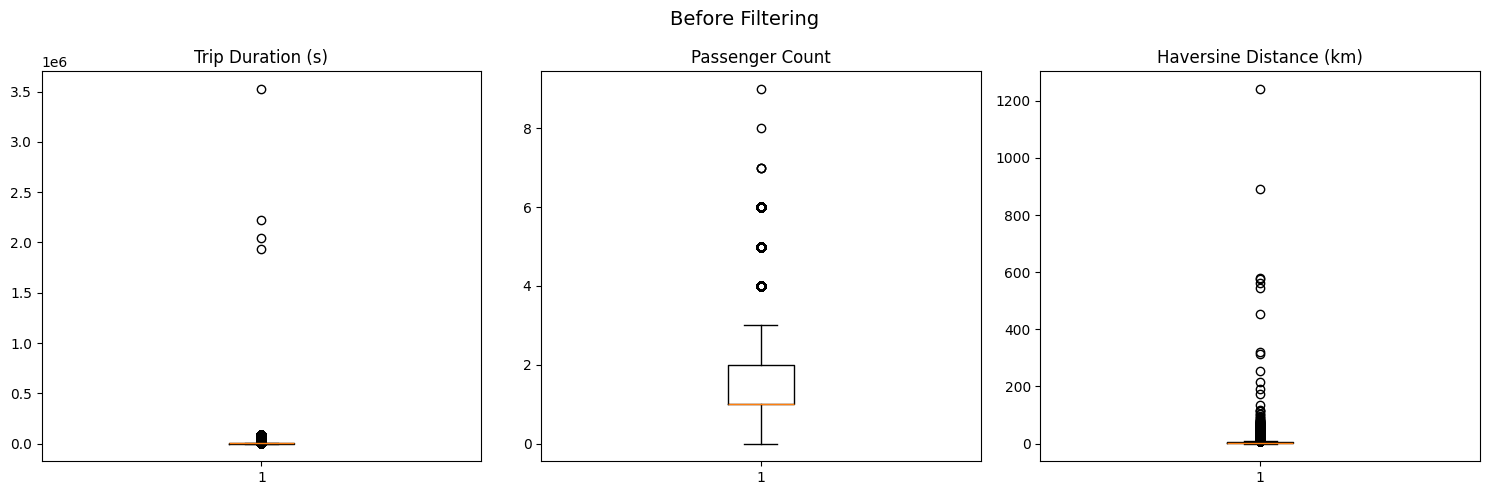

In [48]:
# Before
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].boxplot(df["trip_duration"])
axes[0].set_title("Trip Duration (s)")
axes[1].boxplot(df["passenger_count"])
axes[1].set_title("Passenger Count")
axes[2].boxplot(df["distance_haversine"])
axes[2].set_title("Haversine Distance (km)")
plt.suptitle("Before Filtering", fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
# Outliers removing
df = df[
    (df["trip_duration"] > 0) & (df["trip_duration"] < 86400)
]  # Remove trips with 0 or >24 hour duration (>0 and <24 hours)
df = df[
    df["passenger_count"].between(1, 6)
]  # Remove not possible passenger count for taxi so between 1 to 6
df = df[df["distance_haversine"] > 0.01]  # Remove trips that didn't move anywhere
df = df[
    df["pickup_longitude"].between(-74.05, -73.75)
    & df["pickup_latitude"].between(40.60, 40.90)
    & df["dropoff_longitude"].between(-74.05, -73.75)
    & df["dropoff_latitude"].between(40.60, 40.90)
]  # Only keeping new york city coordinates check citation

After: (1443220, 18)


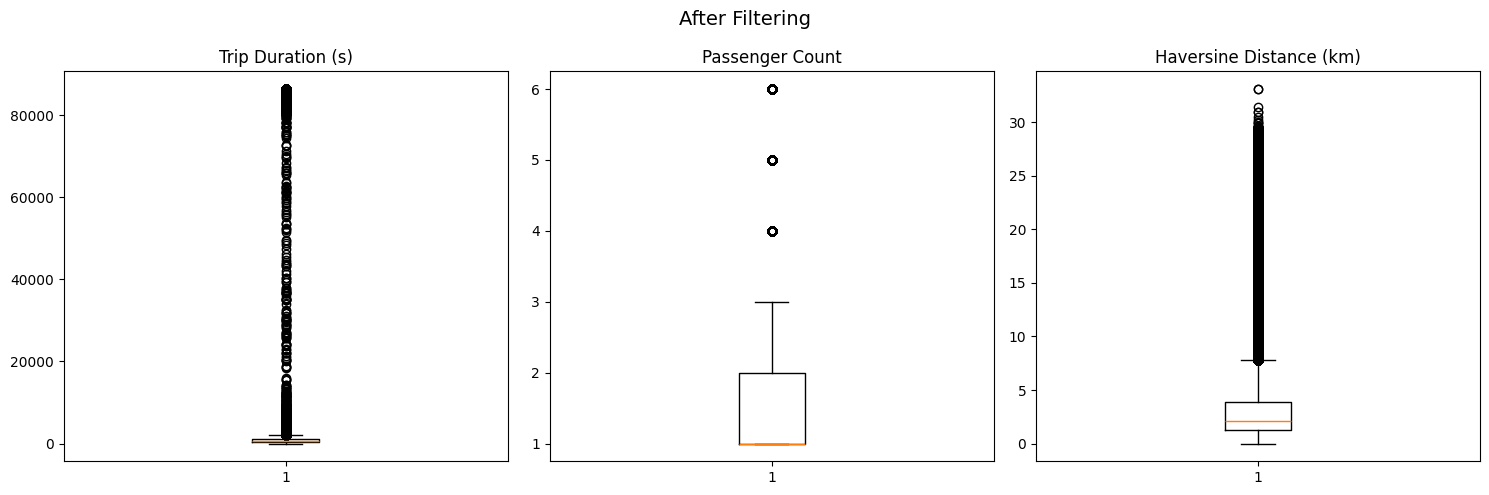

In [50]:
# After removing visalization
print("After:", df.shape)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].boxplot(df["trip_duration"])
axes[0].set_title("Trip Duration (s)")
axes[1].boxplot(df["passenger_count"])
axes[1].set_title("Passenger Count")
axes[2].boxplot(df["distance_haversine"])
axes[2].set_title("Haversine Distance (km)")
plt.suptitle("After Filtering", fontsize=14)
plt.tight_layout()
plt.show()

### Drop Unnecessary Columns


In [51]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
       'pickup_is_weekend', 'distance_haversine', 'distance_manhattan',
       'bearing'],
      dtype='object')

In [52]:
df = df.drop(columns=["id", "pickup_datetime", "dropoff_datetime"])
print(df.shape)
print(df.columns.tolist())

(1443220, 15)
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_is_weekend', 'distance_haversine', 'distance_manhattan', 'bearing']


### Log-Transforming the Target Variable

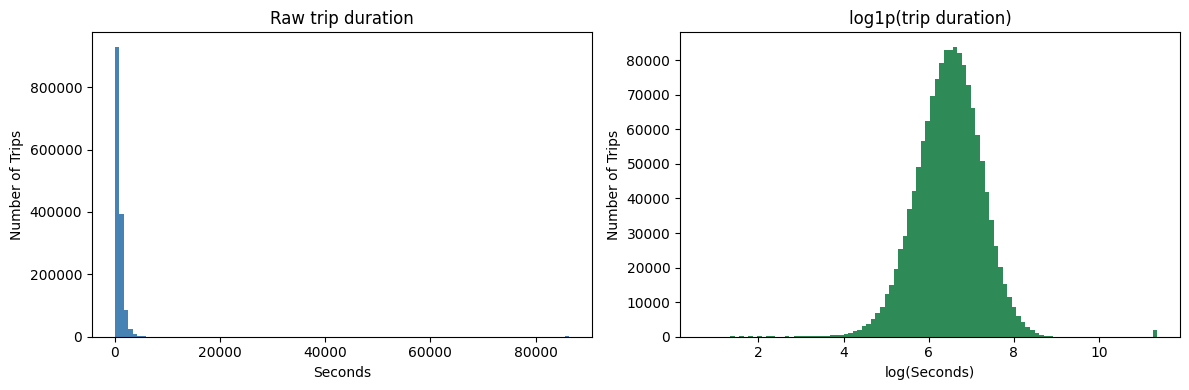

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# before
axes[0].hist(df["trip_duration"], bins=100, color="steelblue")
axes[0].set_title("Raw trip duration")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Number of Trips")

# Log transformed
axes[1].hist(np.log1p(df["trip_duration"]), bins=100, color="seagreen")
axes[1].set_title("log1p(trip duration)")
axes[1].set_xlabel("log(Seconds)")
axes[1].set_ylabel("Number of Trips")

plt.tight_layout()
plt.show()

### Why Use a Log Transform?

| Problem (Raw Target)              | After Log Transform                  |
|-----------------------------------|--------------------------------------|
| Extreme outliers dominate loss    | Outliers are compressed              |
| Right-skewed distribution         | More symmetric distribution          |
| Large values drive model errors   | Errors become more balanced          |
| Unstable variance                 | Variance becomes more stable         |

In [54]:
# Apply log transform to target
df["log_trip_duration"] = np.log1p(df["trip_duration"])
print(df[["trip_duration", "log_trip_duration"]].head())

   trip_duration  log_trip_duration
0            455           6.122493
1            663           6.498282
2           2124           7.661527
3            429           6.063785
4            435           6.077642


In [55]:
df.columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
       'pickup_is_weekend', 'distance_haversine', 'distance_manhattan',
       'bearing', 'log_trip_duration'],
      dtype='object')

### Feature Selection

In [56]:
features = [
    "vendor_id",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "store_and_fwd_flag",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_is_weekend",
    "distance_haversine",
    "distance_manhattan",
    "bearing",
]
target = "log_trip_duration"

In [57]:
print(df[features].info())
print(df[target].info())

<class 'pandas.core.frame.DataFrame'>
Index: 1443220 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1443220 non-null  int64  
 1   passenger_count     1443220 non-null  int64  
 2   pickup_longitude    1443220 non-null  float64
 3   pickup_latitude     1443220 non-null  float64
 4   dropoff_longitude   1443220 non-null  float64
 5   dropoff_latitude    1443220 non-null  float64
 6   store_and_fwd_flag  1443220 non-null  int64  
 7   pickup_hour         1443220 non-null  int32  
 8   pickup_dayofweek    1443220 non-null  int32  
 9   pickup_month        1443220 non-null  int32  
 10  pickup_is_weekend   1443220 non-null  int32  
 11  distance_haversine  1443220 non-null  float64
 12  distance_manhattan  1443220 non-null  float64
 13  bearing             1443220 non-null  float64
dtypes: float64(7), int32(4), int64(3)
memory usage: 143.1 MB
None
<class 'p

In [58]:
X = df[features]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_val.shape)

(1154576, 14) (288644, 14)


In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [52]:
models = {
    "Linear Regression": (LinearRegression(), X_train_scaled, X_val_scaled),
    "Random Forest": (
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        X_train,
        X_val,
    ),
    "XGBoost": (
        XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        X_train,
        X_val,
    ),
}

results = {}
for name, (model, X_tr, X_v) in models.items():
    print(f"⏳Training {name}...")
    start = time.time()

    model.fit(X_tr, y_train)
    print(f" Training done ({time.time() - start:.1f}s)")
    preds = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    results[name] = {"RMSE": rmse, "MAE": mae}
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | Total: {time.time() - start:.1f}s\n")

print("Final Results:")
for name, metrics in sorted(results.items(), key=lambda x: x[1]["RMSE"]):
    print(f"{name:20s} → RMSE: {metrics['RMSE']:.4f} | MAE: {metrics['MAE']:.4f}")

⏳Training Linear Regression...
 Training done (0.6s)
RMSE: 0.5624 | MAE: 0.4161 | Total: 0.6s

⏳Training Random Forest...
 Training done (258.3s)
RMSE: 0.3790 | MAE: 0.2452 | Total: 267.0s

⏳Training XGBoost...
 Training done (5.4s)
RMSE: 0.3778 | MAE: 0.2455 | Total: 5.5s

Final Results:
XGBoost              → RMSE: 0.3778 | MAE: 0.2455
Random Forest        → RMSE: 0.3790 | MAE: 0.2452
Linear Regression    → RMSE: 0.5624 | MAE: 0.4161


### Model Comparison Summary

| Model             | RMSE   | MAE    | Time   | Verdict                  |
|------------------|--------|--------|--------|---------------------------|
| XGBoost          | 0.3778 | 0.2455 | 6.9s   | 👑 Best RMSE              |
| Random Forest    | 0.3790 | 0.2452 | 252.5s | Best MAE, ~36x slower     |
| Linear Regression| 0.5624 | 0.4161 | 1.1s   | Weakest overall        |

---

### Observations

- **XGBoost** achieves the lowest **RMSE (0.3778)** → better at minimizing large errors.
- **Random Forest** achieves the lowest **MAE (0.2452)** → slightly more consistent on average.
- The performance difference is extremely small (**~0.0012 RMSE**).
- Given the similar accuracy and much faster training time, **XGBoost is the clear overall choice**.

In [53]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,  # 30 random combos
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    verbose=2,
)

start = time.time()
search.fit(X_train, y_train)
total_time = time.time() - start

search.fit(X_train, y_train)
print(" Best Params:", search.best_params_)
print(" Best CV RMSE:", -search.best_score_)

# on val set
best_preds = search.best_estimator_.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, best_preds))
val_mae = mean_absolute_error(y_val, best_preds)


print(f"Val RMSE : {val_rmse:.4f} (baseline was 0.3778)")
print(f" Val MAE  : {val_mae:.4f} (baseline was 0.2455)")
print(f" Improvement: {((0.3778 - val_rmse) / 0.3778 * 100):.2f}%")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   9.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=100, reg_alpha=0.5, reg_lambda=1, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=100, reg_alpha=0.5, reg_lambda=1, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3,

In [54]:
print(" Running 5-Fold Cross Validation on best XGBoost model...")
start = time.time()

cv_scores = cross_val_score(
    search.best_estimator_,  # tuned XGBoost
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

print(f"Done in {time.time()-start:.1f}s")
print(f"\n CV RMSE per fold: {-cv_scores.round(4)}")
print(f" Mean RMSE : {-cv_scores.mean():.4f}")
print(f" Std  RMSE : {cv_scores.std():.4f}")

 Running 5-Fold Cross Validation on best XGBoost model...
Done in 155.2s

 CV RMSE per fold: [0.3709 0.3675 0.3725 0.3681 0.3733]
 Mean RMSE : 0.3705
 Std  RMSE : 0.0023


In [55]:
# test set from existing X_val (model never trained on this) and since we don't have test set
X_val2, X_test, y_val2, y_test = train_test_split(
    X_val, y_val, test_size=0.5, random_state=42
)

print(f"X_val2 shape :{X_val2.shape}")
print(f"X_test shape :{X_test.shape}")

# Final evaluation using best XGBoost params
final_preds = search.best_estimator_.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_mae = mean_absolute_error(y_test, final_preds)

print("FINAL MODEL EVALUATION ON TEST SET")
print(f"Test RMSE: {final_rmse:.4f}")
print(f"Test MAE: {final_mae:.4f}")

X_val2 shape :(144322, 14)
X_test shape :(144322, 14)
FINAL MODEL EVALUATION ON TEST SET
Test RMSE: 0.3626
Test MAE: 0.2323


24.166666666666668

In [56]:
joblib.dump(search.best_estimator_, "xgboost_nyc_taxi.pkl")
print("Model saved as 'xgboost_nyc_taxi.pkl'")

# Verify loading
loaded_model = joblib.load("xgboost_nyc_taxi.pkl")
test_check = loaded_model.predict(X_test[:5])
print(f" Load verified — sample predictions: {np.expm1(test_check).round(0)} seconds")

Model saved as 'xgboost_nyc_taxi.pkl'
 Load verified — sample predictions: [1459. 1427.  543.  281.  876.] seconds


|   | joblib                                | pickle                 |
| ----- | ------------------------------------- | ---------------------- |
| Speed | Faster for large numpy arrays         | Slower                 |
| Size  | Smaller file                          | Larger                 |
| Usage | Industry standard for sklearn/XGBoost | General Python objects |

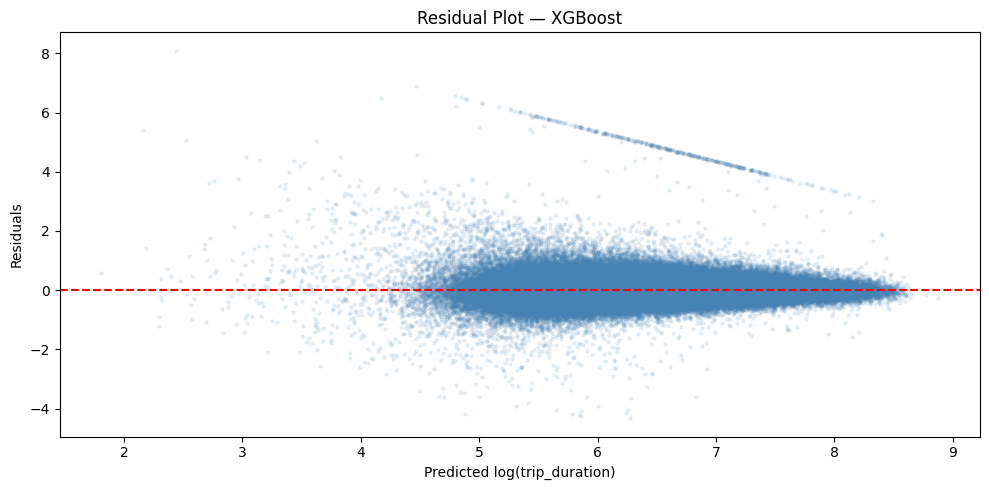

In [57]:
residuals = y_val - search.best_estimator_.predict(X_val)
plt.figure(figsize=(10, 5))
plt.scatter(
    search.best_estimator_.predict(X_val), residuals, alpha=0.1, s=5, color="steelblue"
)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted log(trip_duration)")
plt.ylabel("Residuals")
plt.title("Residual Plot — XGBoost")
plt.tight_layout()
plt.show()

> **Residual Plot Notes**
> - Residuals are centered around **0** → no clear bias.  
> - Diagonal band of large residuals → remaining extreme outliers.  
> - Slight small change in error spread. → variance decreases for longer predicted values.

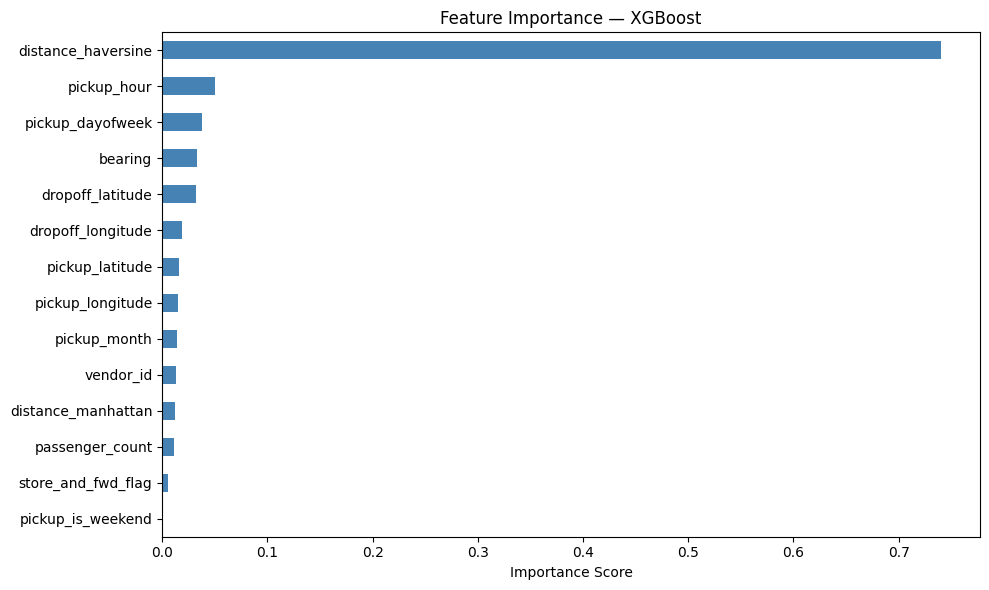

In [58]:
feature_imp = pd.Series(
    search.best_estimator_.feature_importances_, index=features
).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feature_imp.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

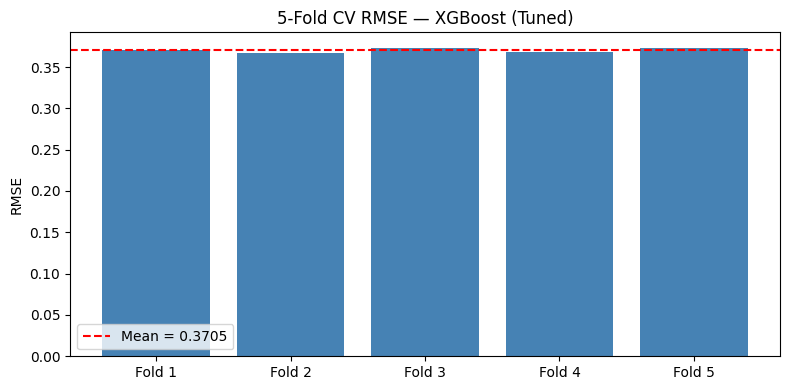

In [59]:
cv_scores = [0.3709, 0.3675, 0.3725, 0.3681, 0.3733]  # results
plt.figure(figsize=(8, 4))
plt.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color="steelblue")
plt.axhline(
    y=np.mean(cv_scores),
    color="red",
    linestyle="--",
    label=f"Mean = {np.mean(cv_scores):.4f}",
)
plt.ylabel("RMSE")
plt.title("5-Fold CV RMSE — XGBoost (Tuned)")
plt.legend()
plt.tight_layout()
plt.show()

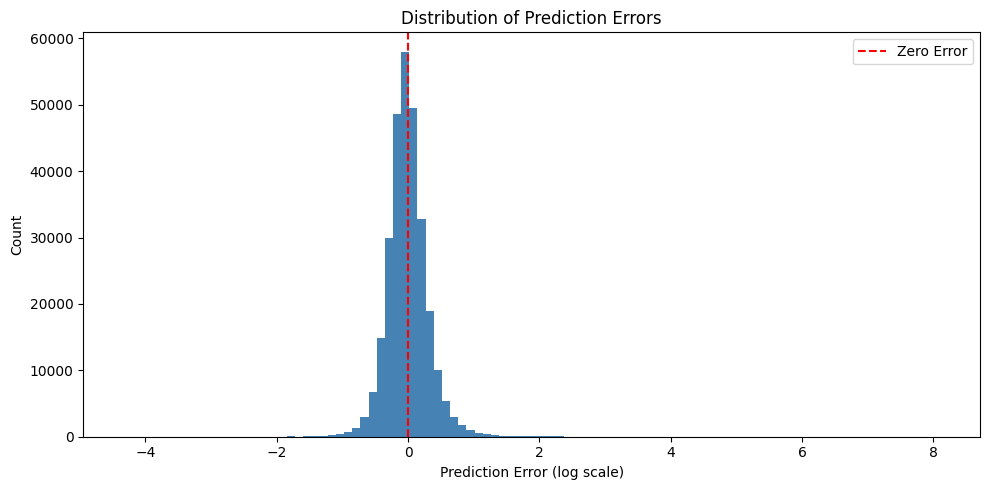

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=100, color="steelblue", edgecolor="none")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error")
plt.xlabel("Prediction Error (log scale)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.legend()
plt.tight_layout()
plt.show()

> **Prediction Error Distribution**
> - Errors are tightly centered around **0** with a near-normal shape → predictions are largely unbiased.  
> - A right-skewed tail (up to +8) indicates remaining extreme outliers.

---
## Ignore

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.base import BaseEstimator, TransformerMixin
# from math import radians, sin, cos, asin, sqrt, atan2, degrees
# import joblib
# import pandas as pd
# class TaxiFeatureEngineer(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         df = X.copy()
#         df['pickup_datetime']= pd.to_datetime(df['pickup_datetime'])
#         df['pickup_hour']= df['pickup_datetime'].dt.hour
#         df['pickup_dayofweek']= df['pickup_datetime'].dt.dayofweek
#         df['pickup_month']= df['pickup_datetime'].dt.month
#         df['pickup_is_weekend']= df['pickup_dayofweek'].isin([5, 6]).astype(int)
#         df['store_and_fwd_flag']=(df['store_and_fwd_flag'] == 'Y').astype(int)
#         df['distance_haversine']=df.apply(self._haversine, axis=1)
#         df['distance_manhattan']=df.apply(self._manhattan, axis=1)
#         df['bearing'] =df.apply(self._bearing,axis=1)

#         return df[[
#             'vendor_id', 'passenger_count',
#             'pickup_longitude', 'pickup_latitude',
#             'dropoff_longitude', 'dropoff_latitude',
#             'store_and_fwd_flag',
#             'pickup_hour', 'pickup_dayofweek', 'pickup_month',
#             'pickup_is_weekend',
#             'distance_haversine', 'distance_manhattan', 'bearing'
#         ]]

#     def _haversine(self, row):
#         lat1, lon1 = radians(row['pickup_latitude']),  radians(row['pickup_longitude'])
#         lat2, lon2 = radians(row['dropoff_latitude']), radians(row['dropoff_longitude'])
#         dlat, dlon = lat2 - lat1, lon2 - lon1
#         a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
#         return 6371 * 2 * asin(sqrt(a))

#     def _manhattan(self, row):
#         return (abs(row['pickup_latitude']  - row['dropoff_latitude']) +
#                 abs(row['pickup_longitude'] - row['dropoff_longitude']))

#     def _bearing(self, row):
#         lat1, lat2 = radians(row['pickup_latitude']), radians(row['dropoff_latitude'])
#         dlon = radians(row['dropoff_longitude'] - row['pickup_longitude'])
#         x = sin(dlon) * cos(lat2)
#         y = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
#         return degrees(atan2(x, y))

# existing_model = joblib.load("xgboost_nyc_taxi.pkl")   # existing file

# pipeline = Pipeline([
#     ('feature_engineer', TaxiFeatureEngineer()),
#     ('model', existing_model)
# ])

# #test
# test = pd.DataFrame([{
#     "vendor_id": 2, "passenger_count": 1,
#     "pickup_longitude": -73.98, "pickup_latitude": 40.76,
#     "dropoff_longitude": -73.96, "dropoff_latitude": 40.75,
#     "store_and_fwd_flag": "N",
#     "pickup_datetime": "2016-03-14 17:24:55"
# }])
# import numpy as np
# print("Predicted seconds:", np.expm1(pipeline.predict(test)[0]))

# joblib.dump(pipeline, "pipeline.pkl")
# print("Done! pipeline.pkl saved")

Predicted seconds: 956.9921
Done! pipeline.pkl saved
